### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 20       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 90 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e7*np.array([1, 1, 1])         ### !!! ### !!! ### !!! ### controls bending strain
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.67907042, 0.82613288, 0.72627431, 0.90380844, 0.3567608 ,
       0.62171624, 0.59289485, 0.85583474, 0.12923438, 0.72242458,
       0.68121314, 0.75994554, 0.33187886, 0.05218471, 0.33538314,
       0.50413059, 0.49244623, 0.94814025, 0.26071164, 0.54488572])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 30)

coefs = [1, 1, 1, 1, 1, 1]
vessel_motion_calibration_coefficient = 1.2e-03 #  for PD controller   ### !!! ### !!! ### !!! ### controls top tension

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.70388289,  0.        ,  0.55273732],
        [ 0.        ,  1.        , -0.62806994],
        [-0.71031604,  0.        ,  0.54773133]],

       [[ 0.73722449,  0.        ,  0.45790303],
        [ 0.        ,  1.        , -0.73531604],
        [-0.67564787,  0.        ,  0.49963501]],

       [[ 0.73616305,  0.        ,  0.50601523],
        [ 0.        ,  1.        , -0.66408872],
        [-0.67680422,  0.        ,  0.55039509]],

       [[ 0.882899  ,  0.        ,  0.29048206],
        [ 0.        ,  1.        , -0.78568859],
        [-0.46956294,  0.        ,  0.54618094]],

       [[ 0.9468497 ,  0.        ,  0.30142132],
        [ 0.        ,  1.        , -0.34924084],
        [-0.32167632,  0.        ,  0.88722941]],

       [[ 0.63367862,  0.        ,  0.6288411 ],
        [ 0.        ,  1.        , -0.58243111],
        [-0.77359641,  0.        ,  0.51510472]],

       [[ 0.54989638,  0.        ,  0.69268087],
        [ 0.        ,  1.        , -0.55876413],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.43484973,  0.        ,  0.26311973],
        [ 0.        ,  0.        , -0.12592921],
        [-0.43091141,  0.        , -0.40992441]],

       [[-0.03032329,  0.        , -0.25309546],
        [ 0.        ,  0.        , -0.37584657],
        [-0.03308687,  0.        , -0.32118011]],

       [[-0.28519846,  0.        , -0.05856766],
        [ 0.        ,  0.        , -0.48323167],
        [-0.31021167,  0.        , -0.52920635]],

       [[-0.39688008,  0.        ,  0.14091251],
        [ 0.        ,  0.        , -0.53779336],
        [-0.74623656,  0.        , -0.84856616]],

       [[-0.08306433,  0.        ,  0.15444168],
        [ 0.        ,  0.        , -0.62274229],
        [-0.24449868,  0.        , -0.29759953]],

       [[-0.71375956,  0.        ,  0.43414819],
        [ 0.        ,  0.        , -0.07417445],
        [-0.58466426,  0.        , -0.61387855]],

       [[-0.57355347,  0.        , -0.07400558],
        [ 0.        ,  0.        , -0.68800487],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 5.55037017e-01,  1.10943021e-01,  3.22181891e-01],
       [ 8.11025160e-01, -6.00956258e-01,  6.41402100e-02],
       [ 8.60121598e-01, -8.29830816e-02, -1.94163502e-02],
       [ 9.52425804e-01,  3.45136902e-01, -6.05770395e-02],
       [ 8.51316150e-01,  9.46070013e-04,  4.39817694e-01],
       [ 1.59370036e-01,  8.28597998e-01,  1.25911052e-02],
       [ 1.11982954e+00,  1.51362310e-01, -2.55981736e-01],
       [ 4.82952108e-01,  6.92067990e-01, -2.92616226e-01],
       [ 4.87527884e-01,  7.98059927e-01,  8.05138288e-01],
       [ 4.13424044e-01,  2.15807321e-02,  5.13917237e-01],
       [ 5.75595501e-01, -2.13510885e-02, -2.09705667e-01],
       [ 8.96009131e-01, -2.42310363e-01,  5.48167870e-01],
       [ 2.46532609e-01,  2.32194889e-01,  3.77404783e-01],
       [ 2.62891797e-01,  7.74503580e-01,  1.56728737e-01],
       [ 7.41632285e-01,  4.16787297e-01,  5.75010097e-01],
       [ 3.46560360e-01,  3.95426703e-01,  4.16147468e-01],
       [ 4.88585867e-01,  2.53005712e-01

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.48018235, -0.16517268, -0.41411887],
       [ 0.66114643, -0.59389995, -0.31672788],
       [ 0.13690174, -0.60048577, -0.29897515],
       [ 0.25847472,  0.46277237, -1.41869012],
       [ 0.845988  ,  0.32833786, -0.47162297],
       [ 0.13256487,  0.77931716, -0.05840872],
       [-0.38620727, -0.27327049, -0.98111616],
       [ 0.19862444,  0.44063453, -0.97937262],
       [ 0.84425489,  0.1238897 , -0.33686624],
       [ 0.70539853, -0.17422402, -0.35535683],
       [ 0.4021062 , -0.05755557, -0.46995693],
       [ 1.14762693, -0.12410978, -0.53556811],
       [ 0.56109347,  0.61879152, -0.05708436],
       [ 0.60039707,  0.35051017, -0.35368593],
       [ 1.27386529, -0.12421055, -0.86209424],
       [ 1.00251789, -0.04103677, -0.26479966],
       [ 0.20426368, -0.15316594, -0.26816161],
       [ 0.75290564,  0.64291016, -0.69467345],
       [ 0.36498127,  0.65083839,  0.05489733],
       [ 0.70455736,  0.12808582,  0.3013564 ]])

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.18262044, 0.06515287, 0.22327359],
       [0.75791056, 0.6349924 , 0.73243525],
       [0.42821256, 0.66684166, 0.03838541],
       [0.78288697, 0.12981084, 0.15866496],
       [0.99782253, 0.84901509, 0.07297115],
       [0.76375754, 0.63577458, 0.63947953],
       [0.8431571 , 0.39576021, 0.17430144],
       [0.10091374, 0.12074503, 0.02934601],
       [0.1936981 , 0.52862972, 0.94988922],
       [0.11567422, 0.08158319, 0.61853781],
       [0.86573987, 0.99358368, 0.21981925],
       [0.91593597, 0.01580263, 0.64837111],
       [0.43620373, 0.66315636, 0.90791407],
       [0.37075972, 0.83065733, 0.31642063],
       [0.36784605, 0.46192717, 0.29575677],
       [0.84184954, 0.0459947 , 0.70100376],
       [0.97008243, 0.28142413, 0.40230725],
       [0.40809443, 0.86086718, 0.32585102],
       [0.09259263, 0.62820198, 0.72561835],
       [0.6829815 , 0.58839846, 0.17578696]])

In [44]:
theta(φ,θ,ψ)

array([[0.67907042, 0.7899471 , 0.60065942],
       [0.82613288, 0.74184315, 0.08995547],
       [0.72627431, 0.7434128 , 0.62836682],
       [0.90380844, 0.48879568, 0.1871167 ],
       [0.3567608 , 0.32749937, 0.38566619],
       [0.62171624, 0.88449711, 0.59588001],
       [0.59289485, 0.98855616, 0.87804669],
       [0.85583474, 0.9290835 , 0.49052015],
       [0.12923438, 0.52451211, 0.74787843],
       [0.72242458, 0.28371247, 0.98088743],
       [0.68121314, 0.7935093 , 0.04159264],
       [0.75994554, 0.18338333, 0.96829487],
       [0.33187886, 0.26813068, 0.30616966],
       [0.05218471, 0.98153017, 0.82636293],
       [0.33538314, 0.23656385, 0.91390518],
       [0.50413059, 0.18483891, 0.29070959],
       [0.49244623, 0.72545857, 0.18683376],
       [0.94814025, 0.83218911, 0.5024591 ],
       [0.26071164, 0.61471095, 0.84526109],
       [0.54488572, 0.50335575, 0.02176002]])

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.19652788,  0.02460481,  0.20720514],
       [ 0.92571245,  0.13151242, -0.0213117 ],
       [ 0.35807847,  0.6509023 , -0.23741354],
       [ 0.7908595 ,  0.01789987,  0.0101861 ],
       [ 0.68897905,  0.78769799, -0.72285729],
       [ 0.88878086,  0.19348484, -0.08190254],
       [ 0.82267614,  0.26560119, -0.2180768 ],
       [ 0.1036958 ,  0.11778864,  0.01682889],
       [ 0.63737612,  0.34578636,  0.70719762],
       [ 0.16535896,  0.01019376,  0.60293409],
       [ 0.59180527,  0.82617484, -0.64773978],
       [ 0.92206164, -0.49844189,  0.38036655],
       [ 0.85033427,  0.2795611 ,  0.37995784],
       [ 0.46779879,  0.71601066, -0.07486799],
       [ 0.45228756,  0.35557114,  0.08310923],
       [ 0.86242785, -0.47686742,  0.42772692],
       [ 0.9950738 , -0.05045212, -0.05096404],
       [ 0.49282137,  0.73154963, -0.11456009],
       [ 0.49952798,  0.56111104,  0.53015656],
       [ 0.6438071 ,  0.4774578 , -0.26564898]])

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.83282306, -0.02978591,  0.55273732],
        [ 0.43980384,  0.64195073, -0.62806994],
        [-0.33612249,  0.76616712,  0.54773133]],

       [[ 0.77887465,  0.42857799,  0.45790303],
        [ 0.06088283,  0.67498415, -0.73531604],
        [-0.62421756,  0.60059745,  0.49963501]],

       [[ 0.8597499 , -0.0691281 ,  0.50601523],
        [ 0.43948907,  0.60484339, -0.66408872],
        [-0.26015278,  0.79333838,  0.55039509]],

       [[ 0.9361186 ,  0.19824766,  0.29048206],
        [ 0.11508025,  0.60782397, -0.78568859],
        [-0.33232289,  0.76892645,  0.54618094]],

       [[ 0.91956233, -0.25209185,  0.30142132],
        [ 0.35248977,  0.86820608, -0.34924084],
        [-0.17365506,  0.42739665,  0.88722941]],

       [[ 0.77734203,  0.0172696 ,  0.6288411 ],
        [ 0.45621862,  0.67278419, -0.58243111],
        [-0.4331327 ,  0.7396372 ,  0.51510472]],

       [[ 0.71031522, -0.12508202,  0.69268087],
        [ 0.63816091,  0.52965394, -0.55876413],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[ 0.10213449, -0.20885572, -0.02259244],
       [ 0.8208018 , -0.86523842, -0.09922314],
       [ 0.10967414, -0.0951168 ,  0.42891289],
       [ 0.096053  , -0.38747676, -0.15693418],
       [-0.17900748,  0.19378538,  0.19310349],
       [ 0.45431612, -0.62446317,  0.07823619],
       [ 0.12430002, -0.24275124, -0.05010378],
       [ 0.07593421, -0.07235335,  0.03658088],
       [ 0.10153857, -0.34724471,  0.17254227],
       [-0.26681347, -0.49806673,  0.11559086],
       [ 0.62862214, -0.51085461, -0.16671171],
       [-0.32230537, -0.06227712,  0.45682977],
       [ 0.02607743, -0.27677613,  0.18963334],
       [-0.04798741, -0.07230499,  0.24604107],
       [-0.37022283,  0.12344483,  0.26766078],
       [ 0.02388679, -0.2475348 , -0.01244472],
       [ 0.31360437, -0.38963243, -0.48363564],
       [ 0.57185286, -0.48419491,  0.56301049],
       [-0.0367296 , -0.44846302,  0.39294245],
       [ 0.23156126, -0.25386006, -0.04995361]])

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 3.69028767e-01, -5.90668471e-01,  3.59605328e-01],
       [ 4.41518859e-01, -4.82488508e-01, -7.58425537e-02],
       [ 3.13235819e-01, -6.41572703e-01,  3.96994594e-01],
       [ 2.21440492e-01, -4.50687246e-01,  1.07709223e-01],
       [-1.17667884e-04, -9.39785230e-02,  7.99133748e-02],
       [ 4.74165989e-01, -5.66231410e-01,  3.45763154e-01],
       [ 5.30903301e-01, -8.76496751e-01,  6.28322425e-01],
       [ 7.32174106e-01, -7.99653681e-01,  2.37146222e-01],
       [ 1.74286088e-02, -2.86829152e-01,  1.98151170e-01],
       [-5.00937712e-01, -5.18071225e-01,  5.18788362e-01],
       [ 3.99247137e-01, -3.36177641e-01, -1.25318163e-01],
       [-5.69466487e-01, -4.28308816e-01,  5.28050111e-01],
       [ 2.85929147e-04, -5.80061556e-02,  5.04894443e-02],
       [ 3.67906895e-01, -5.69231607e-01,  6.52883692e-01],
       [-2.38571987e-01, -2.27803016e-01,  1.46517369e-01],
       [-1.62110266e-02, -7.82310675e-02,  7.78530204e-02],
       [ 2.66703291e-01, -1.89483228e-01

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
#     t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[ 1.02134490e+08, -2.08855716e+08, -2.25924417e+07],
       [ 8.20801796e+08, -8.65238424e+08, -9.92231371e+07],
       [ 1.09674140e+08, -9.51167962e+07,  4.28912888e+08],
       [ 9.60529972e+07, -3.87476763e+08, -1.56934182e+08],
       [-1.79007475e+08,  1.93785376e+08,  1.93103492e+08],
       [ 4.54316123e+08, -6.24463167e+08,  7.82361871e+07],
       [ 1.24300017e+08, -2.42751239e+08, -5.01037847e+07],
       [ 7.59342109e+07, -7.23533518e+07,  3.65808786e+07],
       [ 1.01538570e+08, -3.47244713e+08,  1.72542275e+08],
       [-2.66813466e+08, -4.98066732e+08,  1.15590856e+08],
       [ 6.28622141e+08, -5.10854613e+08, -1.66711707e+08],
       [-3.22305371e+08, -6.22771165e+07,  4.56829771e+08],
       [ 2.60774252e+07, -2.76776128e+08,  1.89633340e+08],
       [-4.79874147e+07, -7.23049891e+07,  2.46041070e+08],
       [-3.70222834e+08,  1.23444826e+08,  2.67660784e+08],
       [ 2.38867906e+07, -2.47534798e+08, -1.24447190e+07],
       [ 3.13604370e+08, -3.89632426e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[-4.13526878e+07,  2.63692120e+06, -2.11321635e+08],
       [-5.11111156e+08, -3.56741641e+08, -1.11722309e+09],
       [ 1.26019616e+08, -3.81678519e+08, -1.16865527e+08],
       [-1.78480220e+08,  1.02811191e+08, -3.63085384e+08],
       [-6.83720153e+06, -1.28386642e+08,  1.22501894e+08],
       [-6.66200076e+07, -1.39197418e+08, -7.24180447e+08],
       [-4.79558167e+07,  3.50279453e+07, -2.88680506e+08],
       [-1.52401715e+07, -6.56060126e+07, -9.81267985e+07],
       [ 2.74307790e+08, -2.47739273e+07, -2.11284082e+08],
       [ 2.08964380e+08, -2.38511711e+08, -5.45373915e+08],
       [-3.64406227e+08, -2.07513656e+08, -7.38187597e+08],
       [-1.86600800e+08, -5.77581022e+08, -2.10390230e+08],
       [ 8.48476203e+07, -7.02430461e+07, -1.14189866e+08],
       [ 2.60915551e+08, -1.95861135e+08, -6.66992087e+06],
       [-1.11053264e+08, -4.22902654e+08,  4.14356187e+07],
       [ 3.84475466e+07,  1.05125602e+07, -1.35305262e+08],
       [-3.87446576e+08,  1.67187736e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 8099929.28066612,  4126909.79224437, -1533546.2942269 ],
       [ 6502362.76381592,  6756974.49579941, -5132300.22418874],
       [ 8526194.95291608,  3261214.78749741, -1456955.04469385],
       [ 8523256.10929952,  3417802.28604479, -3221953.70828523],
       [ 4540468.71187274,  1928089.89402793,  2274128.80986486],
       [ 7686821.25491121,  5374380.52461477, -1740168.47382834],
       [ 9342368.73244899,  4979351.54943948,  -947776.04724732],
       [ 7698837.41638914,  5586826.91620829, -4930977.53989101],
       [ 4832685.34064926,  4281293.14417063,  5772222.78380504],
       [ 8995290.42682164, -3648557.40791827,  5042263.45387702],
       [ 5007984.29093733,  7673169.25573478, -4629213.60311759],
       [ 8751979.77190687, -4836575.42872164,  5515407.0042063 ],
       [ 3967072.3656164 ,  1683745.01634843,  1911949.61660802],
       [ 7150622.69584205,  9384262.31152155,  4152432.28504853],
       [ 5282949.41283733,  -642306.63118458,  7603496.8603052 ],
       [ 5

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-1.16415322e-10,  2.81631296e-11, -4.65661287e-10],
       [ 0.00000000e+00,  1.05652394e-09,  9.31322575e-10],
       [-1.16415322e-10,  6.93170918e-10,  9.31322575e-10],
       [ 0.00000000e+00,  6.80769490e-10,  9.31322575e-10],
       [ 0.00000000e+00, -2.18021987e-10,  2.32830644e-10],
       [ 0.00000000e+00,  9.26885296e-11,  0.00000000e+00],
       [-1.74622983e-10,  5.69371053e-10,  9.31322575e-10],
       [-1.39698386e-09,  1.11564887e-09, -9.31322575e-10],
       [ 0.00000000e+00,  3.37025476e-10, -2.32830644e-10],
       [-6.98491931e-10, -2.58615842e-09, -9.31322575e-10],
       [ 9.31322575e-10, -4.26071903e-10,  4.65661287e-10],
       [ 4.65661287e-10,  1.44549825e-09,  0.00000000e+00],
       [ 1.16415322e-10,  2.27191785e-10, -4.65661287e-10],
       [ 1.39698386e-09, -1.59622526e-09,  1.86264515e-09],
       [-1.74622983e-10,  1.66304067e-09,  2.91038305e-10],
       [-5.82076609e-11, -4.24698454e-11,  1.74622983e-10],
       [-4.65661287e-10,  3.18016288e-10

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[144.6793076 , 263.90171356, 253.39247701],
       [130.22000821,  70.75017668, 191.60628123],
       [152.79672269, 112.68729926,  36.61138665],
       [  4.80534752, 205.86821004,   7.73653215],
       [  0.55188116, 275.57747329, 265.10701088],
       [ 34.64872589, 123.1420179 , 101.88746993],
       [  9.71218228, 111.98687642, 158.97037443],
       [  9.47522191,  29.70583177, 107.80680293],
       [ 17.56956386,  15.50949293,  20.90687956],
       [  8.07963927, 112.69088762, 143.39656295],
       [ 88.75812635, 159.41565906,  62.85011694],
       [  3.04747814,  27.68993558, 205.62071342],
       [129.65233288,  30.86449915,  48.45046817],
       [135.52656167,  14.22101036,  25.63888226],
       [  2.23621315,  66.8024613 , 125.66979037],
       [  7.45277183,  75.05143721, 145.18528881],
       [ 40.55905746,   0.83582157,  22.43980102],
       [  1.71118635, 116.34697836, 129.28915882],
       [102.89534019,  35.38309393,  28.29661552],
       [ 50.15760287,  51.99534

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = phi(x,y,z)*e3+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        for j in range(k.shape[1]):
            if k[i][j]<0:
                k0[i][j]=0
            elif 0<=k[i][j]<=d0/20:
                k0[i][j]=(fg_e2*10*k[i][j]**2)/((d0/8-d0/40)*d0)
            else:
                k0[i][j]=(fg_e2*(k[i][j]-d0/40))/(d0/8-d0/40)
                
    return k0         

In [63]:
sigma(x,y,z)

array([[ 3780.67535398,  3780.67535398, 10287.83442253],
       [ 3780.67535398,  3780.67535398, 25127.01014169],
       [ 3780.67535398,  3780.67535398,  4899.39246872],
       [ 3780.67535398,  3780.67535398,  8404.85918291],
       [ 3780.67535398,  3780.67535398,  5907.37050081],
       [ 3780.67535398,  3780.67535398, 22417.87793363],
       [ 3780.67535398,  3780.67535398,  8860.57391892],
       [ 3780.67535398,  3780.67535398,  4635.94502922],
       [ 3780.67535398,  3780.67535398, 31464.5603448 ],
       [ 3780.67535398,  3780.67535398, 21807.54540825],
       [ 3780.67535398,  3780.67535398, 10187.16024772],
       [ 3780.67535398,  3780.67535398, 22677.01700036],
       [ 3780.67535398,  3780.67535398, 30241.22269046],
       [ 3780.67535398,  3780.67535398, 13002.54261404],
       [ 3780.67535398,  3780.67535398, 12400.30828921],
       [ 3780.67535398,  3780.67535398, 24210.96022337],
       [ 3780.67535398,  3780.67535398, 15505.65062043],
       [ 3780.67535398,  3780.6

In [64]:
def ne_hat(x,y,z,dx,dy,dz):
    ans=fg_e.T - fD(dx,dy,dz) # - sigma(x,y,z).T
    ans[:, :] = 0
    return ans

In [65]:
ne_hat(x,y,z,dx,dy,dz).T

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[130.55185489, -34.71576949,  30.27515484],
        [-34.71576949, 139.44718433, -34.40135796],
        [ 30.27515484, -34.40135796, 130.00096078]],

       [[120.96751874, -33.67034426,  22.87843852],
        [-33.67034426, 154.06896719, -36.73896329],
        [ 22.87843852, -36.73896329, 124.96351408]],

       [[125.60514173, -33.60390095,  27.85082999],
        [-33.60390095, 144.10138288, -36.55111704],
        [ 27.85082999, -36.55111704, 130.29347539]],

       [[108.43798298, -22.82284423,  15.86557666],
        [-22.82284423, 161.73065527, -42.91281287],
        [ 15.86557666, -42.91281287, 129.83136175]],

       [[109.08548142, -10.52686354,  26.74298625],
        [-10.52686354, 112.19691624, -30.98567415],
        [ 26.74298625, -30.98567415, 178.71760234]],

       [[139.54411322, -36.62566221,  32.39190175],
        [-36.62566221, 133.92259993, -30.00130121],
        [ 32.39190175, -30.00130121, 126.53328685]],

       [[147.98067809, -38.70452238,  31.58927487],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 20.47601006945673,
 40.959214573408026,
 61.456810473883436,
 81.97599978887138,
 102.52399212252116,
 123.10800719801298,
 143.7352773939863,
 164.41305028541942,
 185.14859118985243,
 205.94918571985045,
 226.822142342603,
 247.77479494756105,
 268.8145054230128,
 289.948666242506,
 311.18470306202374,
 332.53007732882884,
 353.992288902892,
 375.5788786918262,
 397.2974313002532]

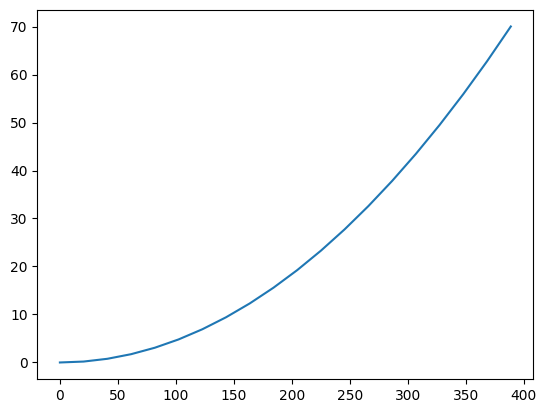

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz).T
    Z = (Z1 + Z2 )


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T)
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    D[:, :-1] = 0
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0)

In [83]:
root_

 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  2.048e+01 ...  0.000e+00  0.000e+00]
  method: hybr
    nfev: 242
    fjac: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -1.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00 -1.000e+00]]
       r: [-0.000e+00  0.000e+00 ...  0.000e+00  7.500e-03]
     qtf: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
q0 = root_.x                                            # start from static solution

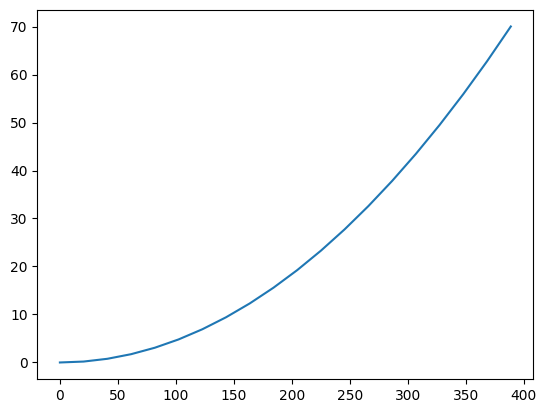

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

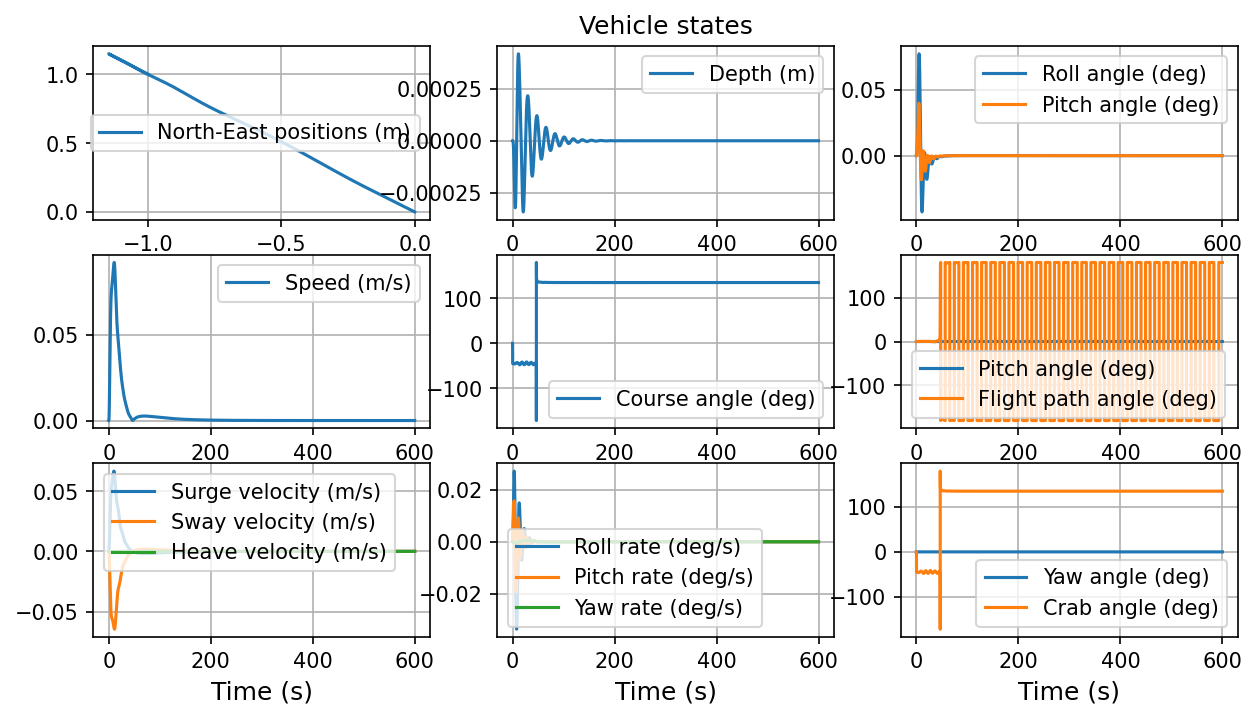

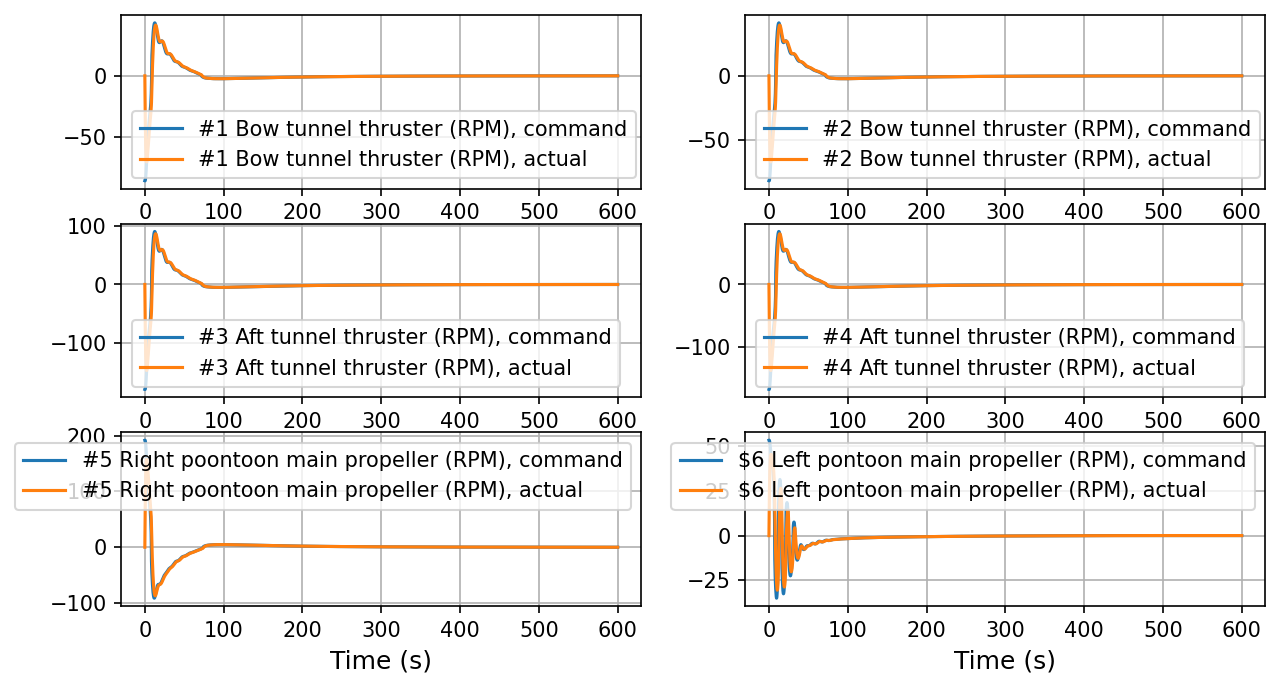

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

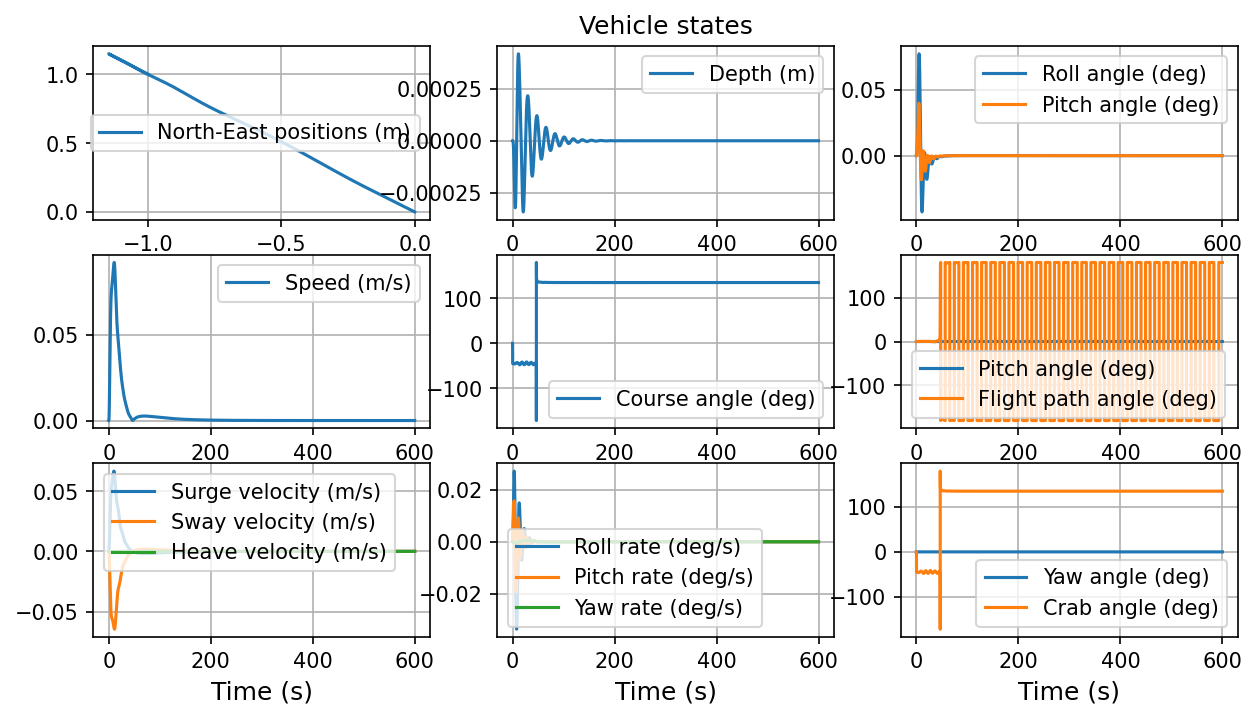

In [95]:
plotVehicleStates(simTime, simData, 3)

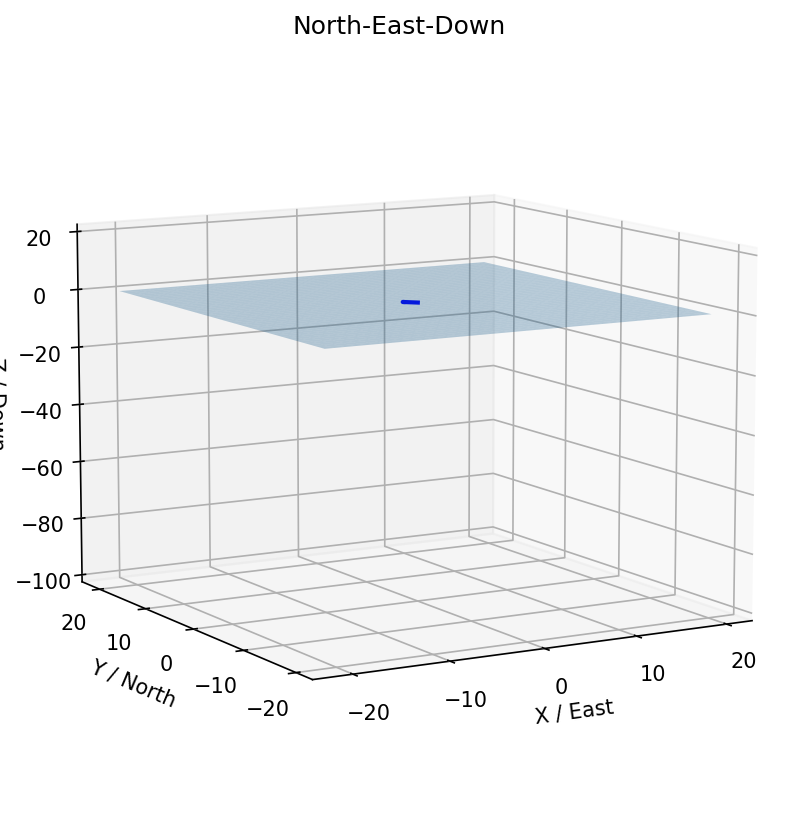

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

### Dynamics

In [99]:
def dynamic_func(t, Q, coefs, T, calibr):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    idx = find_nearest(np.array(ans_t),  t)
    
    x_ve = simData[:, 0][idx]
    y_ve = simData[:, 1][idx]
    z_ve = simData[:, 2][idx]
    phi_ve = simData[:, 3][idx]
    theta_ve = simData[:, 4][idx]
    psi_ve = simData[:, 5][idx]
    

    
    RET = Ret(φ,θ,ψ)
    

    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    x_n=x.copy()
    y_n=y.copy()
    z_n=z.copy()
    x_n[-1]-=x_ve
    y_n[-1]-=y_ve
    z_n[-1]-=z_ve

    Z2 = ne_hat(x_n, y_n, z_n, dx, dy, dz).T
    
    Z = (Z1 + Z2)

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = C1

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    φ_n=φ.copy()
    θ_n=θ.copy()
    ψ_n=ψ.copy()
  
    φ_n[-1]-= phi_ve
    θ_n[-1]-= theta_ve
    ψ_n[-1]-= psi_ve

    D = w_e(φ_n,θ_n,ψ_n,dφ,dθ,dψ)
    D[:, :] = 0
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         

    ans=np.concatenate([dx, ddx, 
                            dy, ddy, 
                            dz, ddz, 
                            dφ, ddφ, 
                            dθ, ddθ,  
                            dψ, ddψ, 
                           ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
        
        T.top_tension=max(T.top_tension, np.max(ax[-1,:]))
    
        ben=np.max(np.einsum('ijk,ik->ij',np.linalg.inv(RET), 
                         me(φ, θ, ψ, φ, θ, ψ)))/(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+
                                                                 (y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagnend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
 
    return ans

In [100]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.0001 for i in range(N)]),
                                          np.array([0.000003 for i in range(N)]),
                                          np.array([0.000019*i/N for i in range(N)]))

In [101]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(coefs, T_, vessel_motion_calibration_coefficient,), 
               )
print(datetime.now() - startTime1)

Physical time:  8.304169741579203e-06  Iteration wall-clock time:  0:00:00.013625
Physical time:  1.2962459264154775  Iteration wall-clock time:  0:00:00.127611
Physical time:  2.4172039307935624  Iteration wall-clock time:  0:00:00.012275
Physical time:  3.2300208547739935  Iteration wall-clock time:  0:00:00.024326
Physical time:  4.547513622337203  Iteration wall-clock time:  0:00:00.011602
Physical time:  5.4648635774582255  Iteration wall-clock time:  0:00:00.023221
Physical time:  6.899420675258086  Iteration wall-clock time:  0:00:00.013022
Physical time:  7.111947652709917  Iteration wall-clock time:  0:00:00.007219
Physical time:  8.087621769511795  Iteration wall-clock time:  0:00:00.023989
Physical time:  9.270980761156945  Iteration wall-clock time:  0:00:00.006412
Physical time:  10.183414321691771  Iteration wall-clock time:  0:00:00.023453
Physical time:  11.500684213322067  Iteration wall-clock time:  0:00:00.012265
Physical time:  12.412806170984407  Iteration wall-clo

In [102]:
# max axial tension
T_.top_tension

1116353.403746296

In [103]:
# max bending strain
T_.sagnend_strain*(mp*9.81*np.sqrt((x[-1]-x0_[-1])**2+(y[-1]-0)**2+(z[-1]-z0_[-1])**2)**2)

0.002462678482302166

### Results

In [104]:
fin=us_

In [105]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.304e-04 ...  2.999e+01  3.000e+01]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 2.048e+01  2.048e+01 ...  2.045e+01  2.045e+01]
            ...
            [ 0.000e+00  2.005e-21 ...  1.925e-18  1.921e-18]
            [ 0.000e+00 -4.892e-21 ... -3.289e-17 -3.289e-17]]
      sol: None
 t_events: None
 y_events: None
     nfev: 140
     njev: 0
      nlu: 0

In [106]:
t=fin.t

In [107]:
fin=fin.y.T

In [108]:
t.shape, fin.shape

((20,), (20, 240))

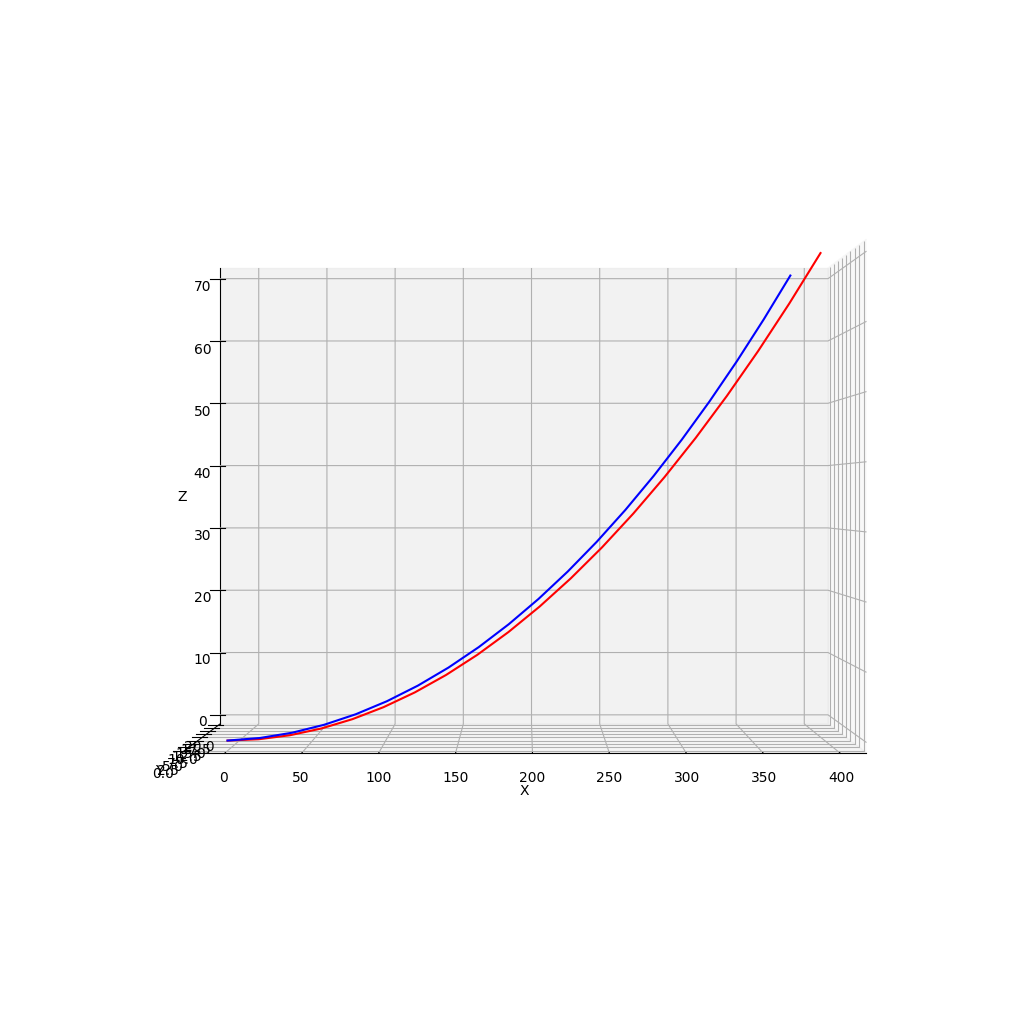

In [109]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [110]:
X,Y,Z

(array([  0.        ,  20.44730928,  40.89435288,  61.34086858,
         81.78661183, 102.23136495, 122.6749467 , 143.11722241,
        163.55811485, 183.99761568, 204.43579792, 224.87282914,
        245.30898569, 265.74466775, 286.18041528, 306.6169248 ,
        327.05506662, 347.49590287, 367.94070542, 388.39097404]),
 array([ 0.        ,  0.92561183,  1.85326252,  2.78504074,  3.72301697,
         4.6692343 ,  5.62569892,  6.5943701 ,  7.57714984,  8.57587171,
         9.59228913, 10.62806302, 11.68474844, 12.76378053, 13.86645949,
        14.99393426, 16.14718729, 17.32701495, 18.53401101, 19.76854494]),
 array([ 0.        ,  0.195486  ,  0.78210739,  1.75979821,  3.12844517,
         4.88788259,  7.03788539,  9.57816031, 12.50833548, 15.82794859,
        19.53643385, 23.63310806, 28.1171561 , 32.98761627, 38.24336583,
        43.88310739, 49.90535646, 56.30843103, 63.0904436 , 70.24929646]))

In [111]:
X0,Y0,Z0

(array([  0.        ,  20.47511082,  40.95022165,  61.42533247,
         81.9004433 , 102.37555412, 122.85066495, 143.32577577,
        163.8008866 , 184.27599742, 204.75110824, 225.22621907,
        245.70132989, 266.17644072, 286.65155154, 307.12666237,
        327.60177319, 348.07688401, 368.55199484, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0.]),
 array([ 0.        ,  0.19189866,  0.76766204,  1.72749246,  3.07172714,
         4.80083838,  6.9154337 ,  9.41625605, 12.30418411, 15.58023255,
        19.24555239, 23.30143144, 27.74929474, 32.59070503, 37.82736334,
        43.46110957, 49.49392312, 55.92792361, 62.76537163, 70.00866951]))

In [112]:
us=fin.T

In [113]:
us.shape

(240, 20)

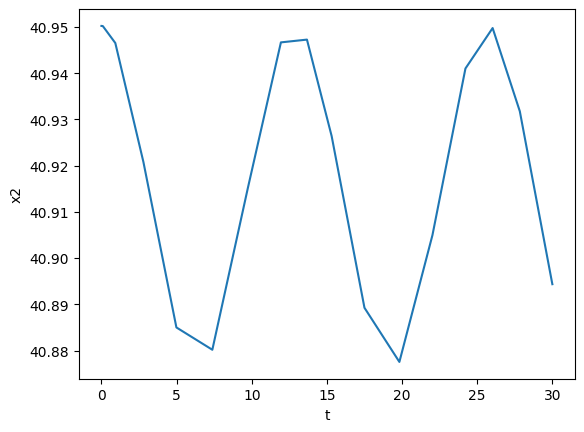

In [114]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

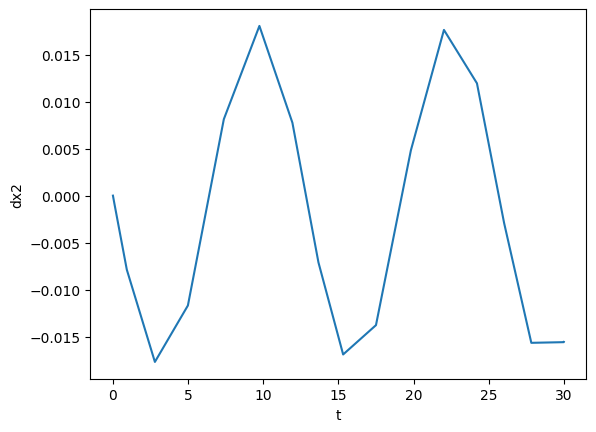

In [115]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

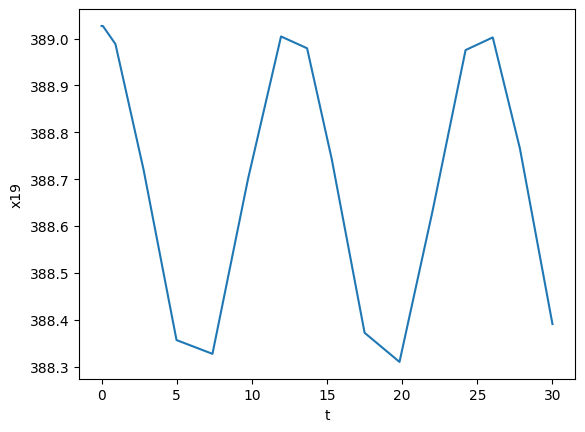

In [116]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

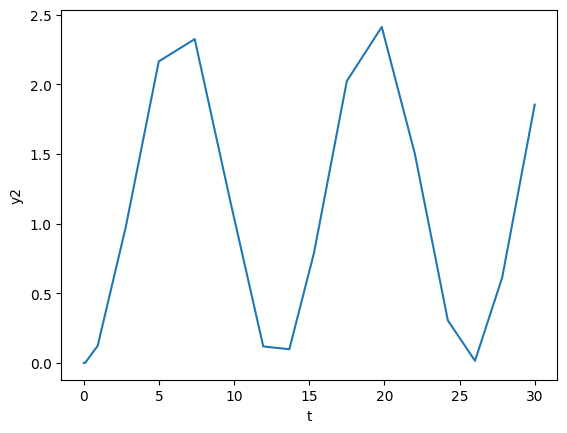

In [117]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

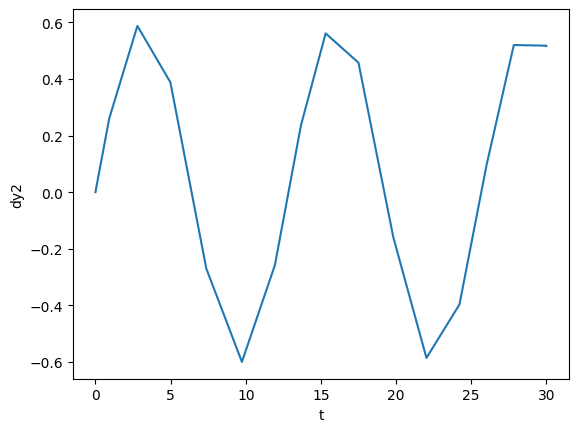

In [118]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

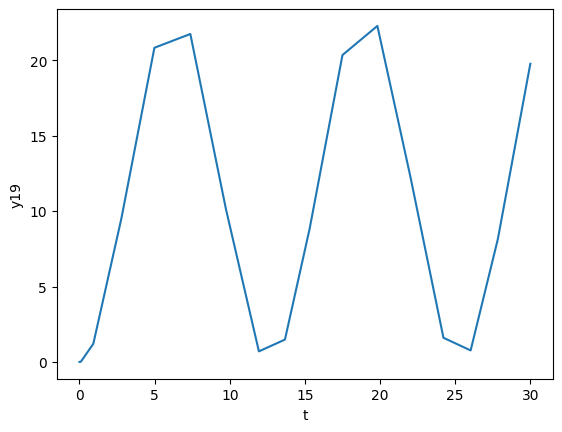

In [119]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

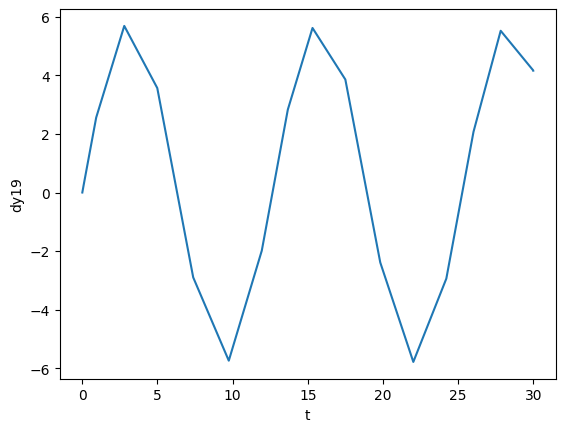

In [120]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

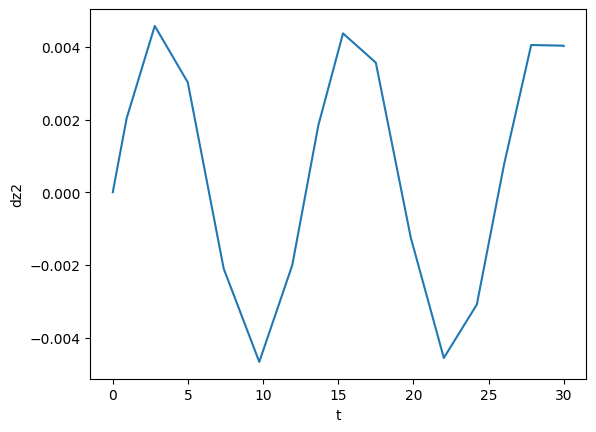

In [121]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

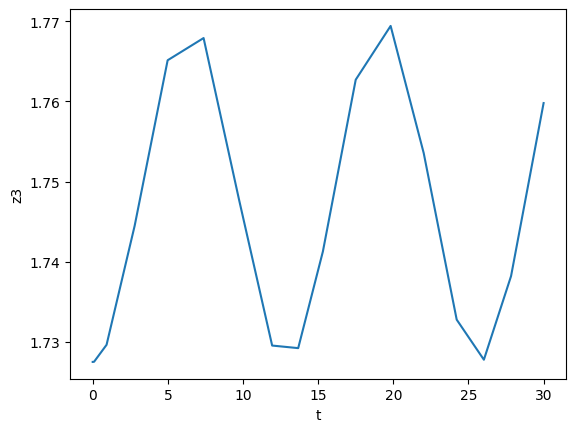

In [122]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

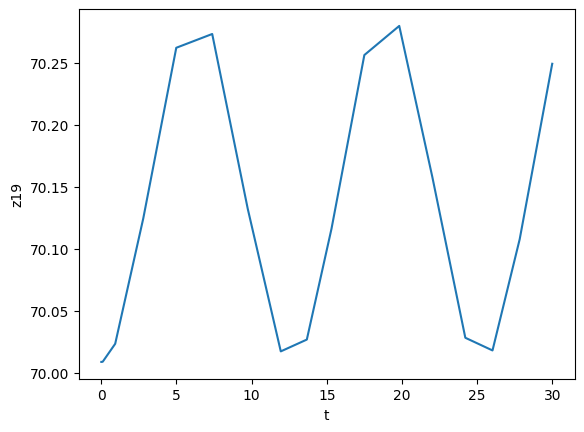

In [123]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

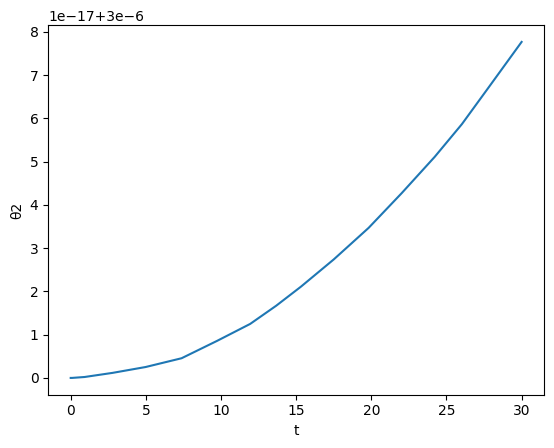

In [124]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

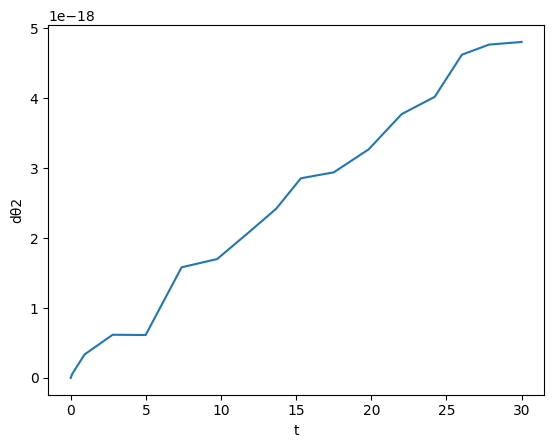

In [125]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

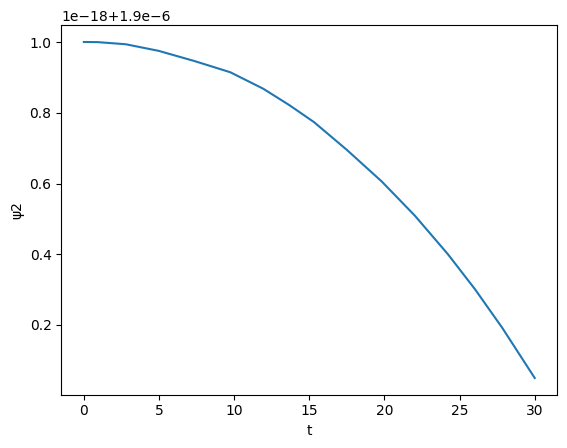

In [126]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

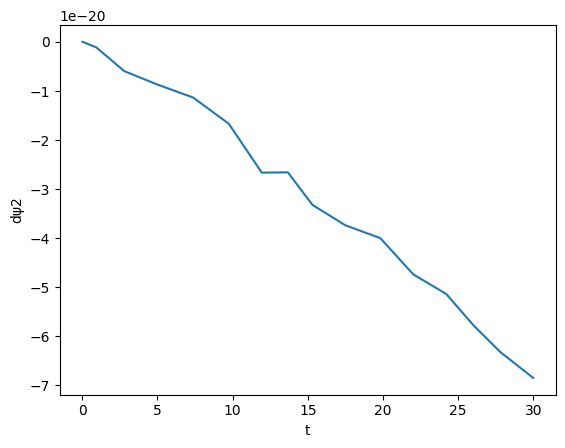

In [127]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

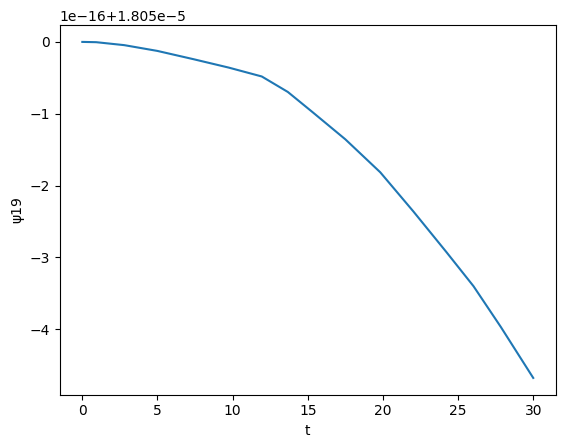

In [128]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [129]:
X010=us.T[:,0*N:1*N]

In [130]:
Y010=us.T[:,2*N:3*N]

In [131]:
Z010=us.T[:,4*N:5*N]

In [132]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 10                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()